In [3]:
!pip install tensorflow scikit-learn imbalanced-learn -q

import os, json, cv2, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.regularizers import l2
import tensorflow as tf

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
DATASET_PATH = "/kaggle/input/datasets/dgvdeelaka/handwritten-datatset/dataset"
IMG_SIZE     = 80   # matches dataset recommendation (was 64 — wrong!)
BATCH_SIZE   = 32   # smaller batch = more stable gradients
EPOCHS       = 100

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
NUM_CLASSES = len(classes)
print(f"Total classes: {NUM_CLASSES}")
print("First 10:", classes[:10])

# Check class balance
counts = []
for c in classes:
    n = len(os.listdir(os.path.join(DATASET_PATH, c)))
    counts.append(n)
print(f"Min samples: {min(counts)}, Max: {max(counts)}, Mean: {np.mean(counts):.0f}")

Total classes: 410
First 10: ['අ', 'ආ', 'ඇ', 'ඈ', 'ඉ', 'ඊ', 'උ', 'එ', 'ඒ', 'ඔ']
Min samples: 185, Max: 199, Mean: 192


In [6]:
def load_and_preprocess(fpath, img_size):
    img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)
    coords = cv2.findNonZero(img)
    if coords is None:
        return None
    x, y, w, h = cv2.boundingRect(coords)
    margin = max(2, int(max(w, h) * 0.05))
    x = max(0, x - margin)
    y = max(0, y - margin)
    w = min(img.shape[1] - x, w + 2*margin)
    h = min(img.shape[0] - y, h + 2*margin)
    img = img[y:y+h, x:x+w]
    size = max(img.shape[0], img.shape[1])
    ph, pw = size - img.shape[0], size - img.shape[1]
    padded = cv2.copyMakeBorder(img, ph//2, ph-ph//2, pw//2, pw-pw//2,
                                 cv2.BORDER_CONSTANT, value=0)
    return cv2.resize(padded, (img_size, img_size), interpolation=cv2.INTER_AREA)

# Load with progress counter so you can see it's working
images, labels = [], []
for idx, char_class in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, char_class)
    files = os.listdir(class_path)
    for fname in files:
        img = load_and_preprocess(os.path.join(class_path, fname), IMG_SIZE)
        if img is not None:
            images.append(img)
            labels.append(idx)
    if idx % 10 == 0:
        print(f"  Loaded class {idx+1}/{NUM_CLASSES}: {char_class} — total so far: {len(images)}")

# Store as uint8 first (uses 4x less RAM), normalize later
X = np.array(images, dtype=np.uint8)
y_int = np.array(labels, dtype=np.int32)
print(f"Raw array shape: {X.shape}, RAM: {X.nbytes / 1e6:.0f} MB")

# Now normalize (float32 only when needed)
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype(np.float32) / 255.0
y = to_categorical(y_int, num_classes=NUM_CLASSES)
print(f"Final X shape: {X.shape}")

  Loaded class 1/410: අ — total so far: 192
  Loaded class 11/410: ඕ — total so far: 2112
  Loaded class 21/410: කා — total so far: 4032
  Loaded class 31/410: ඛා — total so far: 5952
  Loaded class 41/410: ගා් — total so far: 7872
  Loaded class 51/410: ඝ්‍ර — total so far: 9794
  Loaded class 61/410: ඝූ — total so far: 11714
  Loaded class 71/410: ඟූ — total so far: 13634
  Loaded class 81/410: චි — total so far: 15554
  Loaded class 91/410: ජා් — total so far: 17474
  Loaded class 101/410: ට්‍ර් — total so far: 19394
  Loaded class 111/410: ඨ — total so far: 21318
  Loaded class 121/410: ඩ්‍ර — total so far: 23238
  Loaded class 131/410: ඩූ — total so far: 25158
  Loaded class 141/410: ණ් — total so far: 27075
  Loaded class 151/410: ඬැ — total so far: 28987
  Loaded class 161/410: ත්‍රී — total so far: 30907
  Loaded class 171/410: ථැ — total so far: 32816
  Loaded class 181/410: දැ — total so far: 34736
  Loaded class 191/410: ධැ — total so far: 36656
  Loaded class 201/410: න්‍රා

In [9]:
X_train, X_test, y_train, y_test, yi_train, yi_test = train_test_split(
    X, y, y_int, test_size=0.15, random_state=42, stratify=y_int)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.12, random_state=42)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

# Compute class weights to handle imbalanced classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(yi_train),
    y=yi_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weight range: {min(class_weights):.2f} – {max(class_weights):.2f}")

Train: 58870  Val: 8028  Test: 11806
Class weight range: 0.97 – 1.03


In [10]:
datagen = ImageDataGenerator(
    rotation_range=8,         # Sinhala strokes are sensitive — keep small
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    shear_range=3,            # reduced: shear distorts curved strokes
    fill_mode='constant',     # black fill (matches white-on-black setup)
    cval=0
)
datagen.fit(X_train)

In [11]:
model = Sequential([
    # ── Block 1 ─────────────────────────────
    Conv2D(32, (3,3), padding='same', activation='relu',
           kernel_regularizer=l2(1e-4),
           input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.20),

    # ── Block 2 ─────────────────────────────
    Conv2D(64, (3,3), padding='same', activation='relu',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # ── Block 3 ─────────────────────────────
    Conv2D(128, (3,3), padding='same', activation='relu',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    # ── Block 4 (extra for 80px input) ──────
    Conv2D(256, (3,3), padding='same', activation='relu',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(256, (3,3), padding='same', activation='relu',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.35),

    # ── Classifier head ─────────────────────
    # GlobalAveragePooling2D instead of Flatten
    # → far fewer parameters → less overfitting
    GlobalAveragePooling2D(),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.50),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.40),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776793007.224782      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776793007.230400      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,545,850 (5.90 MB)

 Trainable params: 1,542,906 (5.89 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('sinhala_cnn.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    class_weight=class_weight_dict,   # ← handles imbalanced classes
    callbacks=callbacks,
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✓ Test accuracy: {acc:.2%}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1776793024.899605     143 service.cc:152] XLA service 0x7803880033d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776793024.899652     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776793024.899655     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776793026.271567     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-21 17:37:10.457724: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal

   5/1839 ━━━━━━━━━━━━━━━━━━━━ 1:09 38ms/step - accuracy: 0.0012 - loss: 6.6540      

I0000 00:00:1776793039.327697     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  48/1839 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.0027 - loss: 6.7126

...

1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9375 - loss: 0.5563 - val_accuracy: 0.9356 - val_loss: 0.6323 - learning_rate: 2.5000e-04
Epoch 71/100
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8875 - loss: 0.7571
Epoch 71: val_accuracy did not improve from 0.93560
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.8875 - loss: 0.7571 - val_accuracy: 0.9283 - val_loss: 0.6377 - learning_rate: 2.5000e-04
Epoch 72/100
   1/1839 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.9062 - loss: 0.7510
Epoch 72: val_accuracy did not improve from 0.93560
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9062 - loss: 0.7510 - val_accuracy: 0.9279 - val_loss: 0.6381 - learning_rate: 2.5000e-04
Epoch 73/100
1838/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8886 - loss: 0.7514
Epoch 73: val_accuracy improved from 0.93560 to 0.93635, saving model to sinhala_cnn.h5


1839/1839 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.8886 - loss: 0.7514 - val_accuracy: 0.9363 - val_loss: 0.6191 - learning_rate: 2.5000e-04
Epoch 74/100
   1/1839 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.9375 - loss: 0.5290
Epoch 74: val_accuracy did not improve from 0.93635
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9375 - loss: 0.5290 - val_accuracy: 0.9363 - val_loss: 0.6192 - learning_rate: 2.5000e-04
Epoch 75/100
1837/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8902 - loss: 0.7405
Epoch 75: val_accuracy improved from 0.93635 to 0.93722, saving model to sinhala_cnn.h5


1839/1839 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.8902 - loss: 0.7405 - val_accuracy: 0.9372 - val_loss: 0.6009 - learning_rate: 2.5000e-04
Epoch 76/100
   1/1839 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.9375 - loss: 0.5968
Epoch 76: val_accuracy improved from 0.93722 to 0.93734, saving model to sinhala_cnn.h5


1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9375 - loss: 0.5968 - val_accuracy: 0.9373 - val_loss: 0.6010 - learning_rate: 2.5000e-04
Epoch 77/100
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8893 - loss: 0.7286
Epoch 77: val_accuracy did not improve from 0.93734
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.8893 - loss: 0.7286 - val_accuracy: 0.9368 - val_loss: 0.6031 - learning_rate: 2.5000e-04
Epoch 78/100
   1/1839 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9375 - loss: 0.6425
Epoch 78: val_accuracy did not improve from 0.93734
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9375 - loss: 0.6425 - val_accuracy: 0.9371 - val_loss: 0.6031 - learning_rate: 2.5000e-04
Epoch 79/100
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8943 - loss: 0.7065
Epoch 79: val_accuracy improved from 0.93734 to 0.94083, saving model to sinhala_cnn.h5


1839/1839 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.8943 - loss: 0.7065 - val_accuracy: 0.9408 - val_loss: 0.5935 - learning_rate: 2.5000e-04
Epoch 80/100
   1/1839 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.9062 - loss: 0.6313
Epoch 80: val_accuracy did not improve from 0.94083
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9062 - loss: 0.6313 - val_accuracy: 0.9406 - val_loss: 0.5930 - learning_rate: 2.5000e-04
Epoch 81/100
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8939 - loss: 0.7083
Epoch 81: val_accuracy did not improve from 0.94083
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.8939 - loss: 0.7083 - val_accuracy: 0.9375 - val_loss: 0.5872 - learning_rate: 2.5000e-04
Epoch 82/100
   1/1839 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.8438 - loss: 0.7861
Epoch 82: val_accuracy did not improve from 0.94083
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8438 - loss: 0.7861 - val_accuracy: 0.9375 - val_loss: 0.5869 - lea

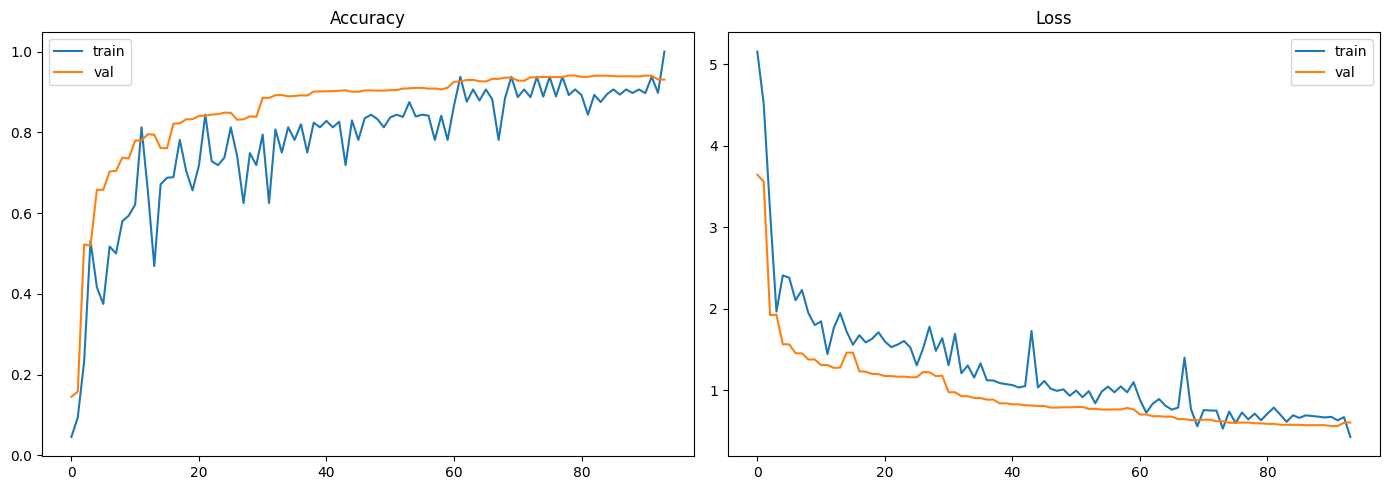

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],    label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy'); ax1.legend()

ax2.plot(history.history['loss'],         label='train')
ax2.plot(history.history['val_loss'],     label='val')
ax2.set_title('Loss'); ax2.legend()

plt.tight_layout(); plt.show()

# Diagnosis guide:
# train acc high, val acc low  → overfitting. Increase dropout or get more data.
# both acc low                 → underfitting. Add more conv layers or epochs.
# val acc jumpy                → reduce learning rate or increase batch size.

In [14]:
label_map = {str(idx): char for idx, char in enumerate(classes)}

with open("label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print("Saved. First 5 entries:")
print(json.dumps(dict(list(label_map.items())[:5]), ensure_ascii=False, indent=2))

Saved. First 5 entries:
{
  "0": "අ",
  "1": "ආ",
  "2": "ඇ",
  "3": "ඈ",
  "4": "ඉ"
}


In [15]:
from IPython.display import FileLink
display(FileLink('sinhala_cnn.h5'))
display(FileLink('label_map.json'))

/kaggle/working/sinhala_cnn.h5

/kaggle/working/label_map.json